<a href="https://colab.research.google.com/github/shanchepngen-ux/ML-For-Engineering/blob/main/Week4_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Assigment- Statistical Analysis
**Note on Dataset Selection**

I had to use a different dataset for this assignment because my original dataset contains images, which were not suitable for the numerical statistical analysis required. Therefore, I used the NASA Global Landslide Catalog, which provided numerical data appropriate for calculating descriptive statistics, covariance, and Pearson correlation, as well as creating a scatter plot.


In [8]:
import pandas as pd

url = "https://data.nasa.gov/docs/legacy/Global_Landslide_Catalog_Export/Global_Landslide_Catalog_Export_rows.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())
print(df.select_dtypes(include="number").columns.tolist())

Dataset shape: (11033, 31)

Column names:
['source_name', 'source_link', 'event_id', 'event_date', 'event_time', 'event_title', 'event_description', 'location_description', 'location_accuracy', 'landslide_category', 'landslide_trigger', 'landslide_size', 'landslide_setting', 'fatality_count', 'injury_count', 'storm_name', 'photo_link', 'notes', 'event_import_source', 'event_import_id', 'country_name', 'country_code', 'admin_division_name', 'admin_division_population', 'gazeteer_closest_point', 'gazeteer_distance', 'submitted_date', 'created_date', 'last_edited_date', 'longitude', 'latitude']


,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,location_accuracy,landslide_category,...,country_code,admin_division_name,admin_division_population,gazeteer_closest_point,gazeteer_distance,submitted_date,created_date,last_edited_date,longitude,latitude
0,AGU,https://blogs.agu.org/landslideblog/2008/10/14...,684,08/01/2008 12:00:00 AM,NaN,"Sigou Village, Loufan County, Shanxi Province","occurred early in morning, 11 villagers buried...","Sigou Village, Loufan County, Shanxi Province",unknown,landslide,...,CN,Shaanxi,0.0,Jingyang,41.02145,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,107.4500,32.5625
1,Oregonian,http://www.oregonlive.com/news/index.ssf/2009/...,956,01/02/2009 02:00:00 AM,NaN,"Lake Oswego, Oregon",Hours of heavy rain are to blame for an overni...,"Lake Oswego, Oregon",5km,mudslide,...,US,Oregon,36619.0,Lake Oswego,0.60342,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-122.6630,45.4200
2,CBS News,https://www.cbsnews.com/news/dozens-missing-af...,973,01/19/2007 12:00:00 AM,NaN,"San Ramon district, 195 miles northeast of the...",(CBS/AP) At least 10 people died and as many a...,"San Ramon district, 195 miles northeast of the...",10km,landslide,...,PE,Junín,14708.0,San Ramón,0.85548,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-75.3587,-11.1295
3,Reuters,https://in.reuters.com/article/idINIndia-41450...,1067,07/31/2009 12:00:00 AM,NaN,Dailekh district,"One person was killed in Dailekh district, pol...",Dailekh district,unknown,landslide,...,NP,Mid Western,20908.0,Dailekh,0.75395,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,81.7080,28.8378
4,The Freeman,http://www.philstar.com/cebu-news/621414/lands...,2603,10/16/2010 12:00:00 PM,NaN,sitio Bakilid in barangay Lahug,Another landslide in sitio Bakilid in barangay...,sitio Bakilid in barangay Lahug,5km,landslide,...,PH,Central Visayas,798634.0,Cebu City,2.02204,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,123.8978,10.3336


['event_id', 'event_time', 'fatality_count', 'injury_count', 'event_import_id', 'admin_division_population', 'gazeteer_distance', 'longitude', 'latitude']


In [14]:
# Select four numerical variables from the dataset
variables = [
    "fatality_count",
    "injury_count",
    "gazeteer_distance",
    "latitude"
]

data = df[variables].copy()

# Convert columns to numeric and handle missing or infinite values
import numpy as np

data = data.apply(pd.to_numeric, errors="coerce")
data = data.replace([np.inf, -np.inf], np.nan)

print("Selected variables:")
display(data.head())

print("\nMissing values:")
print(data.isnull().sum())

Selected variables:


,fatality_count,injury_count,gazeteer_distance,latitude
0,11.0,NaN,41.02145,32.5625
1,0.0,NaN,0.60342,45.4200
2,10.0,NaN,0.85548,-11.1295
3,1.0,NaN,0.75395,28.8378
4,0.0,NaN,2.02204,10.3336



Missing values:
fatality_count       1385
injury_count         5674
gazeteer_distance    1562
latitude                0
dtype: int64


In [12]:
# Let's calculate the mean, median, range, variance, and standard deviation using Python.

statistics = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "Variance": data.var(),
    "Standard Deviation": data.std()
})

display(statistics.round(3))

,Mean,Median,Range,Variance,Standard Deviation
fatality_count,3.219,0.000,5000.000,3586.354,59.886
injury_count,0.752,0.000,374.000,71.554,8.459
gazeteer_distance,11.874,6.255,215.449,243.305,15.598
latitude,25.882,30.534,119.402,416.774,20.415


In [26]:
# Let's pick two variables and calculate their covariance and correlation


# Select the two variables and remove missing observations
pair_data = data[["gazeteer_distance", "injury_count"]].dropna()

# Calculate covariance
covariance = pair_data["gazeteer_distance"].cov(
    pair_data["injury_count"]
)

# Calculate Pearson correlation
correlation = pair_data["gazeteer_distance"].corr(
    pair_data["injury_count"]
)

# Display results
print("Number of paired observations:", len(pair_data))
print("Covariance:", round(covariance, 4))
print("Pearson correlation:", round(correlation, 4))

Number of paired observations: 3883
Covariance: 3.1764
Pearson correlation: 0.0234


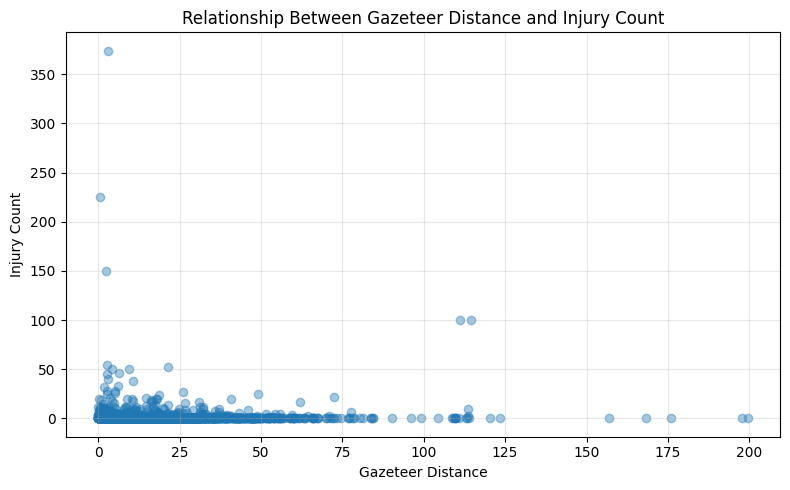

In [27]:
# Plot showing the relationship between the two variables.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(pair_data["gazeteer_distance"],
    pair_data["injury_count"],
    alpha=0.4
)

plt.xlabel("Gazeteer Distance")
plt.ylabel("Injury Count")
plt.title("Relationship Between Gazeteer Distance and Injury Count")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of the Relationship Between Gazeteer Distance and Injury Count
The scatter plot shows the relationship between gazeteer distance and injury counts in the NASA Global Landslide Catalog. Most observations are heavily concentrated near the horizontal axis and close to smaller distances, indicating that for the vast majority of recorded events, injury counts remain very low regardless of gazeteer distance. However, a small number of events exhibit exceptionally high injury counts (reaching nearly 375 injuries) or very high gazeteer distances (approaching 200), producing prominent outliers and a strongly skewed distribution.
   
The scatter plot does not show a clear linear pattern across all observations. The Pearson correlation coefficient is therefore useful for quantifying the direction and strength of the linear relationship. The correlation value should be interpreted alongside the plot because extreme observations, such as the isolated high-injury points at low distances or high-distance points near zero injuries, may heavily influence the result.   

Correlation does not imply causation. Even if gazeteer distance and injury count exhibit a statistical correlation, this does not mean that distance directly determines the number of injuries. Both variables may be influenced by underlying factors such as population density near the gazeteer location, landslide magnitude, reporting accuracy, geocoding precision, and local emergency response capabilities.   


## Conclusion

This assignment used the NASA Global Landslide Catalog to explore numerical data related to landslide events. Descriptive statistics—including the mean, median, range, variance, and standard deviation—were used to examine the distribution and variability of selected numerical variables. Covariance and Pearson correlation were used to investigate the relationship between gazeteer distance and injury counts, and a scatter plot was created to visualize this relationship.

The plot indicates that most recorded events are clustered near smaller gazeteer distances with low injury counts, while a small number of isolated events exhibit exceptionally high injury counts or unusually large gazeteer distances. These extreme observations demonstrate that both spatial distance metrics and injury data are highly skewed. The Pearson correlation coefficient provides a numerical measure of the linear relationship between gazeteer distance and injuries, but it does not establish a causal relationship.
